# OTel Release Energy Analysis (Clean Version)

This notebook is streamlined to produce exactly 4 outputs:
1. Total energy per release with workload filtering (workstation and EC2).
2. Fixed-utilisation energy per request over releases (workstation and EC2).
3. Total attributed energy for a selected workload over releases (workstation and EC2).
4. Attributed energy per request for a selected microservice (default: product-catalog) over releases.

In [38]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

# ---- User inputs ----
# Provide exactly 3 releases here: label -> folder path
RELEASE_PATHS = {
    'v1.12.0': Path('../final-runs/context-runs/eoan_20260612_150921_702343_otel-demo-1.12.0'),
    'v2.0.0': Path('../final-runs/context-runs/eoan_20260612_194821_154588_otel-demo-2.0.0'),
    'v2.2.0': Path('../final-runs/context-runs/eoan_20260612_115311_222031_otel-demo-2.2.0'),
}

# Workload filter for outputs 1, 2 and 4 (single value or list)
WORKLOAD_FILTER = ['medium']

# Hard quality filter: keep only runs with error_rate <= threshold.
MAX_ERROR_RATE = 0.01

# Output 3 workload (single value)
ATTRIBUTION_WORKLOAD = 'medium'

# Model used in attribution payload
ATTRIBUTION_MODEL = 'M1'

# Output 3c services: one or more services to compare against Application total
TARGET_SERVICES = ['cart']

# Output 4 microservice name (uses first service from TARGET_SERVICES by default)
TARGET_SERVICE = TARGET_SERVICES[0]

# Additional output: top N services in attribution breakdown chart
SERVICE_BREAKDOWN_TOP_N = 10

# Optional: services to exclude from Output 3b by exact name (case-insensitive)
EXCLUDED_SERVICES = ['load-generator']

# Fixed-utilisation setting for outputs 2 and 4: choose one percentile directly
TARGET_PERCENTILE = 80
PERCENTILE_CANDIDATES = [int(TARGET_PERCENTILE)]

# Visual toggle for simple 3-release charts (Outputs 2, 3, 4):
# False -> release on x-axis (default orientation)
# True  -> release on y-axis (rotated orientation)
SWAP_SIMPLE_RELEASE_AXES = True

# EPR source for output 2: 'model_only' or 'meter_preferred'
FIXED_UTIL_EPR_SOURCE = 'model_only'

# Figure export settings
FIGURES_DIR = Path('figures')
SAVE_FIGURES = True

ENV_ORDER = ['workstation', 'ec2']
WORKLOAD_ORDER = ['low', 'medium', 'high']
RELEASE_ORDER = list(RELEASE_PATHS.keys())

if len(RELEASE_PATHS) != 3:
    raise ValueError('RELEASE_PATHS must contain exactly 3 releases.')

missing_release_paths = [label for label, p in RELEASE_PATHS.items() if not p.exists()]
if missing_release_paths:
    raise FileNotFoundError(f'Missing release paths: {missing_release_paths}')

def as_workload_list(v) -> list[str]:
    if isinstance(v, str):
        return [v.lower()]
    return [str(x).lower() for x in v]

def slugify(text: str) -> str:
    s = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(text))
    while '__' in s:
        s = s.replace('__', '_')
    return s.strip('_')

def save_figure(fig, stem: str) -> None:
    if not bool(globals().get('SAVE_FIGURES', True)):
        return
    out_dir = Path(globals().get('FIGURES_DIR', Path('figures')))
    out_dir.mkdir(parents=True, exist_ok=True)
    safe_stem = slugify(stem)
    png_path = out_dir / f'{safe_stem}.png'
    pdf_path = out_dir / f'{safe_stem}.pdf'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f'Saved figure: {png_path} and {pdf_path}')

SELECTED_WORKLOADS = as_workload_list(WORKLOAD_FILTER)
if not SELECTED_WORKLOADS:
    raise ValueError('WORKLOAD_FILTER cannot be empty.')

TARGET_SERVICES = [str(s).strip() for s in TARGET_SERVICES if str(s).strip()]
if not TARGET_SERVICES:
    raise ValueError('TARGET_SERVICES must contain at least one service name.')
TARGET_SERVICE = TARGET_SERVICES[0]

print('Configured releases:', RELEASE_ORDER)
print('Selected workloads:', SELECTED_WORKLOADS)
print(f'Hard quality filter: error_rate <= {float(MAX_ERROR_RATE):.4f}')
print(f'Target fixed-util percentile: p{int(TARGET_PERCENTILE)}')
print('Swap simple release chart axes:', SWAP_SIMPLE_RELEASE_AXES)
print('Figure output dir:', FIGURES_DIR.resolve())
print('Output 3c services:', TARGET_SERVICES)
print('Output 4 service:', TARGET_SERVICE)

Configured releases: ['v1.12.0', 'v2.0.0', 'v2.2.0']
Selected workloads: ['medium']
Hard quality filter: error_rate <= 0.0100
Target fixed-util percentile: p80
Swap simple release chart axes: True
Figure output dir: /Users/eoan/Sites/univaq/phd/energyAnalyser/controller/visualizations/figures
Output 3c services: ['cart']
Output 4 service: cart


In [39]:
def extract_json_object_after_marker(text: str, marker: str) -> dict:
    marker_idx = text.find(marker)
    if marker_idx < 0:
        raise ValueError(f'Marker not found: {marker}')

    start = text.find('{', marker_idx)
    if start < 0:
        raise ValueError('Could not find JSON object start after marker')

    depth = 0
    in_string = False
    escaped = False

    for i in range(start, len(text)):
        ch = text[i]

        if in_string:
            if escaped:
                escaped = False
            elif ch == '\\':
                escaped = True
            elif ch == '"':
                in_string = False
            continue

        if ch == '"':
            in_string = True
            continue

        if ch == '{':
            depth += 1
        elif ch == '}':
            depth -= 1
            if depth == 0:
                return json.loads(text[start:i + 1])

    raise ValueError('Could not find end of JSON object')

def environment_from_folder(name: str) -> str | None:
    if name.startswith('eoan_'):
        return 'workstation'
    if name.startswith('julian_'):
        return 'ec2'
    return None

def extract_iteration_name(run_name: str) -> str | None:
    s = pd.Series([str(run_name)])
    it = s.str.extract(r'(iteration_[0-9_]+)', expand=False).iloc[0]
    return None if pd.isna(it) else str(it)

def first_numeric_value(run: dict, keys: list[str]) -> float:
    for key in keys:
        val = pd.to_numeric(run.get(key), errors='coerce')
        if pd.notna(val):
            return float(val)
    return float('nan')

def iter_experiment_dirs(release_dir: Path):
    # New context-run layout: release_dir itself is the experiment folder.
    if (release_dir / 'runs_comparison.html').exists():
        env = environment_from_folder(release_dir.name)
        if env is not None:
            return [(release_dir, env)]

    # Legacy layout: release_dir contains multiple experiment folders.
    out = []
    for experiment_dir in sorted(release_dir.iterdir()):
        if not experiment_dir.is_dir():
            continue
        env = environment_from_folder(experiment_dir.name)
        if env is None:
            continue
        out.append((experiment_dir, env))
    return out

def load_release_data(release_paths: dict[str, Path]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    run_rows = []
    attr_rows = []
    cpu_rows = []

    for release, release_dir in release_paths.items():
        experiments = iter_experiment_dirs(release_dir)
        if not experiments:
            print(
                f'WARNING: no experiment folders detected for release={release} at {release_dir}. '
                'Expected either a top-level runs_comparison.html or nested eoan_/julian_ folders.'
            )
            continue

        for experiment_dir, env in experiments:
            dashboard_path = experiment_dir / 'runs_comparison.html'
            payload = {}
            if dashboard_path.exists():
                payload = extract_json_object_after_marker(
                    dashboard_path.read_text(encoding='utf-8'),
                    'const data = ',
                )

            for run in payload.get('runs', []):
                workload = str(run.get('workload_level', '')).lower()
                if workload not in WORKLOAD_ORDER:
                    continue

                run_name = str(run.get('name', ''))
                iteration_name = extract_iteration_name(run_name)

                model_epr_j = pd.to_numeric(run.get('energy_per_request'), errors='coerce')
                meter_epr_j = pd.to_numeric(run.get('meter_energy_per_request_joules'), errors='coerce')

                total_energy_j = first_numeric_value(
                    run,
                    ['meter_corrected_energy_joules', 'energy_total', 'total_system_energy_j'],
                )

                request_count = first_numeric_value(
                    run,
                    [
                        'requests',
                        'request_count',
                        'total_requests',
                        'successful_requests',
                        'num_requests',
                        'num_requests_total',
                    ],
                )

                if pd.isna(request_count) and pd.notna(total_energy_j):
                    fallback_epr = meter_epr_j if pd.notna(meter_epr_j) else model_epr_j
                    if pd.notna(fallback_epr) and fallback_epr > 0:
                        request_count = float(total_energy_j) / float(fallback_epr)

                run_rows.append({
                    'release': release,
                    'environment': env,
                    'workload_level': workload,
                    'experiment_folder': experiment_dir.name,
                    'run_name': run_name,
                    'iteration_name': iteration_name,
                    'total_energy_j': pd.to_numeric(total_energy_j, errors='coerce'),
                    'model_epr_j': model_epr_j,
                    'meter_epr_j': meter_epr_j,
                    'request_count': pd.to_numeric(request_count, errors='coerce'),
                    'error_rate': pd.to_numeric(run.get('error_rate'), errors='coerce'),
                })

            workloads_payload = ((payload.get('attribution_phase1') or {}).get('workloads') or {})
            for workload_name, workload_payload in workloads_payload.items():
                wl = str(workload_name).lower()
                if wl not in WORKLOAD_ORDER:
                    continue

                for model_name, model_payload in (workload_payload.get('models') or {}).items():
                    services = model_payload.get('services') or {}
                    for service_name, stats in services.items():
                        attr_rows.append({
                            'release': release,
                            'environment': env,
                            'workload_level': wl,
                            'model': str(model_name),
                            'service': str(service_name),
                            'mean_attributed_energy_j': pd.to_numeric(stats.get('mean'), errors='coerce'),
                            'std_attributed_energy_j': pd.to_numeric(stats.get('std'), errors='coerce'),
                            'experiment_folder': experiment_dir.name,
                        })

            for workload_dir in sorted(experiment_dir.iterdir()):
                if not workload_dir.is_dir():
                    continue

                wl = workload_dir.name.lower()
                if wl not in WORKLOAD_ORDER:
                    continue

                for iteration_dir in sorted(workload_dir.glob('iteration_*')):
                    cpu_json_path = iteration_dir / 'cpu_total.json'
                    if not cpu_json_path.exists():
                        continue

                    payload_cpu = json.loads(cpu_json_path.read_text(encoding='utf-8'))
                    series = (((payload_cpu.get('data') or {}).get('result')) or [])
                    values = (series[0].get('values') or []) if series else []
                    cpu_vals = pd.Series(pd.to_numeric([v[1] for v in values], errors='coerce')).dropna()
                    if cpu_vals.empty:
                        continue

                    row = {
                        'release': release,
                        'environment': env,
                        'workload_level': wl,
                        'experiment_folder': experiment_dir.name,
                        'iteration_name': iteration_dir.name,
                        'cpu_mean': float(cpu_vals.mean()),
                    }
                    arr = cpu_vals.to_numpy()
                    for p in PERCENTILE_CANDIDATES:
                        row[f'cpu_p{p}'] = float(np.percentile(arr, p))
                    cpu_rows.append(row)

    runs_df = pd.DataFrame(run_rows)
    attr_df = pd.DataFrame(attr_rows)
    cpu_df = pd.DataFrame(cpu_rows)

    if not runs_df.empty:
        max_error = float(globals().get('MAX_ERROR_RATE', 0.01))
        keep_mask = pd.to_numeric(runs_df.get('error_rate'), errors='coerce').le(max_error).fillna(False)
        before = len(runs_df)
        runs_df = runs_df[keep_mask].copy()
        dropped = before - len(runs_df)
        print(
            f'Applied hard quality filter (error_rate <= {max_error:.4f}): '
            f'kept {len(runs_df)} / {before}, dropped {dropped}.'
        )

    for df in [runs_df, attr_df, cpu_df]:
        if df.empty:
            continue
        df['release'] = pd.Categorical(df['release'], categories=RELEASE_ORDER, ordered=True)
        if 'workload_level' in df.columns:
            df['workload_level'] = pd.Categorical(df['workload_level'], categories=WORKLOAD_ORDER, ordered=True)
        if 'environment' in df.columns:
            df['environment'] = pd.Categorical(df['environment'], categories=ENV_ORDER, ordered=True)

    return runs_df, attr_df, cpu_df

runs_df, attr_df, cpu_df = load_release_data(RELEASE_PATHS)
if runs_df.empty:
    raise RuntimeError(
        'No run rows parsed from the selected release paths after quality filtering. '
        'Check path layout and MAX_ERROR_RATE setting.'
    )
if attr_df.empty:
    print('WARNING: attribution rows are empty.')
if cpu_df.empty:
    print('WARNING: cpu percentile rows are empty; output 2 may fail.')

print('Runs rows:', len(runs_df))
print('Attribution rows:', len(attr_df))
print('CPU rows:', len(cpu_df))

Applied hard quality filter (error_rate <= 0.0100): kept 58 / 60, dropped 2.
Runs rows: 58
Attribution rows: 132
CPU rows: 60


Output 1 summary:


,environment,release,workload_level,mean,std,count
0,workstation,v1.12.0,medium,9.510931,0.367192,20
1,workstation,v2.0.0,medium,9.499759,0.327390,20
2,workstation,v2.2.0,medium,9.483327,0.421246,18


Saved figure: figures/output1_workstation_medium.png and figures/output1_workstation_medium.pdf


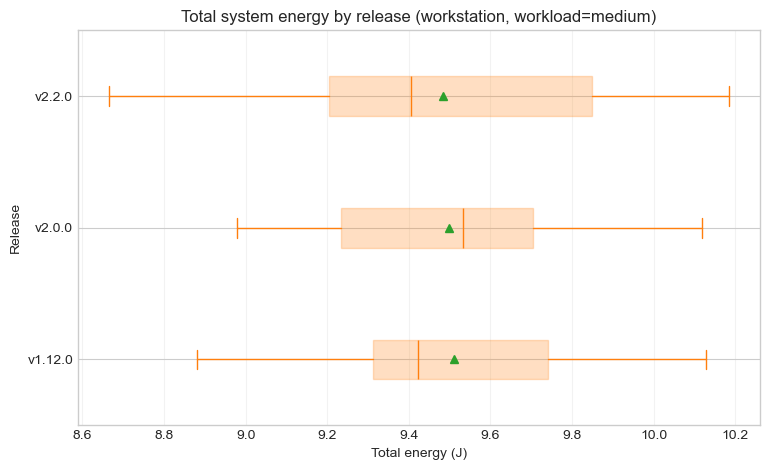

In [40]:
# Output 1: Total energy per release (filterable workloads), for workstation and EC2
runs_wl = runs_df[runs_df['workload_level'].isin(SELECTED_WORKLOADS)].copy()

if runs_wl.empty:
    raise RuntimeError(f'No runs found for workload filter: {SELECTED_WORKLOADS}')

total_energy_summary = (
    runs_wl.groupby(['environment', 'release', 'workload_level'], observed=True)['total_energy_j']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values(['environment', 'workload_level', 'release'])
    .reset_index(drop=True)
)

print('Output 1 summary:')
display(total_energy_summary.round(6))

colors = {'low': '#1f77b4', 'medium': '#ff7f0e', 'high': '#2ca02c'}
swap_axes = bool(globals().get('SWAP_SIMPLE_RELEASE_AXES', False))

for env in ENV_ORDER:
    env_data = runs_wl[runs_wl['environment'] == env].copy()
    if env_data.empty:
        continue

    for wl in SELECTED_WORKLOADS:
        wl_data = env_data[env_data['workload_level'] == wl].copy()
        if wl_data.empty:
            continue

        data = []
        labels = []
        for rel in RELEASE_ORDER:
            vals = pd.to_numeric(
                wl_data.loc[wl_data['release'] == rel, 'total_energy_j'],
                errors='coerce',
            ).dropna()
            if vals.empty:
                continue
            data.append(vals.to_numpy())
            labels.append(str(rel))

        if not data:
            continue

        color = colors.get(wl, '#4c78a8')
        fig, ax = plt.subplots(figsize=(7.8, 4.8))
        bp = ax.boxplot(
            data,
            tick_labels=labels,
            vert=not swap_axes,
            patch_artist=True,
            showmeans=True,
        )
        for box in bp['boxes']:
            box.set(facecolor=color, alpha=0.25, edgecolor=color)
        for key in ['whiskers', 'caps', 'medians', 'means']:
            for artist in bp[key]:
                artist.set(color=color)

        ax.set_title(f'Total system energy by release ({env}, workload={wl})')
        if swap_axes:
            ax.set_ylabel('Release')
            ax.set_xlabel('Total energy (J)')
            ax.grid(True, axis='x', alpha=0.25)
        else:
            ax.set_xlabel('Release')
            ax.set_ylabel('Total energy (J)')
            ax.grid(True, axis='y', alpha=0.25)

        fig.tight_layout()
        save_figure(fig, f'output1_{env}_{wl}')
        plt.show()

Output 2 percentile mode: direct selection p80
Output 2 summary:


,environment,release,mean,std,count
0,workstation,v1.12.0,0.001208,0.000047,20
1,workstation,v2.0.0,0.001206,0.000041,20
2,workstation,v2.2.0,0.001205,0.000052,18


Saved figure: figures/output2_workstation_p80.png and figures/output2_workstation_p80.pdf


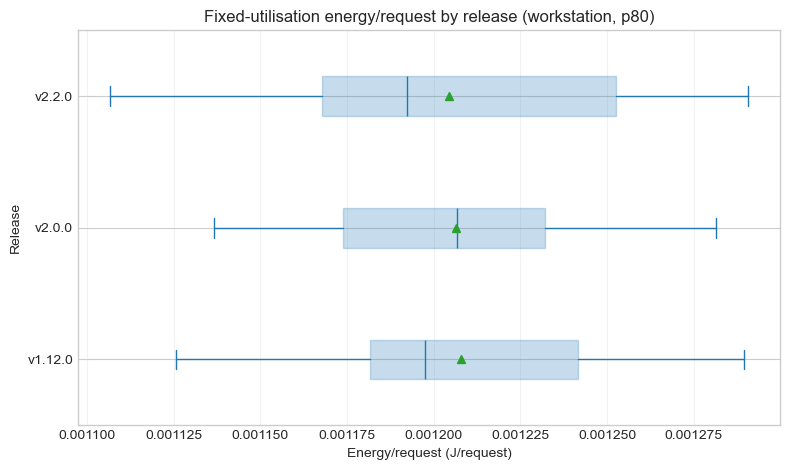

In [41]:
# Output 2: Overall system energy/request over releases at fixed utilisation (workstation and EC2)
runs_epr = runs_df.copy()
if FIXED_UTIL_EPR_SOURCE == 'model_only':
    runs_epr['energy_per_request_j'] = runs_epr['model_epr_j']
elif FIXED_UTIL_EPR_SOURCE == 'meter_preferred':
    runs_epr['energy_per_request_j'] = runs_epr['meter_epr_j'].where(
        runs_epr['meter_epr_j'].notna(),
        runs_epr['model_epr_j'],
    )
else:
    raise ValueError(f'Unsupported FIXED_UTIL_EPR_SOURCE: {FIXED_UTIL_EPR_SOURCE}')

runs_epr = runs_epr[runs_epr['workload_level'].isin(SELECTED_WORKLOADS)].copy()
runs_epr = runs_epr.dropna(subset=['iteration_name', 'energy_per_request_j'])

cpu_wl = cpu_df[cpu_df['workload_level'].isin(SELECTED_WORKLOADS)].copy()
if cpu_wl.empty:
    raise RuntimeError('CPU dataframe is empty for the selected workloads.')

selected_percentile = int(TARGET_PERCENTILE)
selected_cpu_col = f'cpu_p{selected_percentile}'
if selected_cpu_col not in cpu_wl.columns:
    raise RuntimeError(
        f'{selected_cpu_col} is not available in cpu_df. '
        'Re-run setup/loader with matching percentile settings.'
    )

join_keys = ['release', 'environment', 'workload_level', 'experiment_folder', 'iteration_name']
fixed_util_df = cpu_wl.merge(
    runs_epr[join_keys + ['energy_per_request_j']],
    on=join_keys,
    how='inner',
)

if fixed_util_df.empty:
    raise RuntimeError('No rows after CPU/runs join for fixed-util analysis.')

# Direct percentile mode: keep rows that have the requested CPU percentile available.
fixed_util_selected = fixed_util_df.dropna(subset=[selected_cpu_col]).copy()

if fixed_util_selected.empty:
    raise RuntimeError(
        f'No rows remain after selecting percentile p{selected_percentile}. '
        'Try a different TARGET_PERCENTILE.'
    )

fixed_util_summary = (
    fixed_util_selected.groupby(['environment', 'release'], observed=True)['energy_per_request_j']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values(['environment', 'release'])
    .reset_index(drop=True)
)

print(f'Output 2 percentile mode: direct selection p{selected_percentile}')
print('Output 2 summary:')
display(fixed_util_summary.round(6))

style_map = {
    'workstation': {'color': '#1f77b4'},
    'ec2': {'color': '#d62728'},
}
swap_axes = bool(globals().get('SWAP_SIMPLE_RELEASE_AXES', False))

for env in ENV_ORDER:
    env_rows = fixed_util_selected[fixed_util_selected['environment'] == env].copy()
    if env_rows.empty:
        continue

    data = []
    labels = []
    for rel in RELEASE_ORDER:
        vals = pd.to_numeric(
            env_rows.loc[env_rows['release'] == rel, 'energy_per_request_j'],
            errors='coerce',
        ).dropna()
        if vals.empty:
            continue
        data.append(vals.to_numpy())
        labels.append(str(rel))

    if not data:
        continue

    color = style_map[env]['color']
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    bp = ax.boxplot(
        data,
        tick_labels=labels,
        vert=not swap_axes,
        patch_artist=True,
        showmeans=True,
    )
    for box in bp['boxes']:
        box.set(facecolor=color, alpha=0.25, edgecolor=color)
    for key in ['whiskers', 'caps', 'medians', 'means']:
        for artist in bp[key]:
            artist.set(color=color)

    ax.set_title(f'Fixed-utilisation energy/request by release ({env}, p{selected_percentile})')
    if swap_axes:
        ax.set_ylabel('Release')
        ax.set_xlabel('Energy/request (J/request)')
        ax.grid(True, axis='x', alpha=0.25)
    else:
        ax.set_xlabel('Release')
        ax.set_ylabel('Energy/request (J/request)')
        ax.grid(True, axis='y', alpha=0.25)

    fig.tight_layout()
    save_figure(fig, f'output2_{env}_p{selected_percentile}')
    plt.show()

## Output 3: Total energy attribution of a selected workload over releases (workstation and EC2)

Output 3 summary:


,environment,release,mean,std,count
0,workstation,v1.12.0,205.334463,NaN,1
1,workstation,v2.0.0,205.696695,NaN,1
2,workstation,v2.2.0,200.227086,NaN,1


Saved figure: figures/output3_workstation_medium_m1.png and figures/output3_workstation_medium_m1.pdf


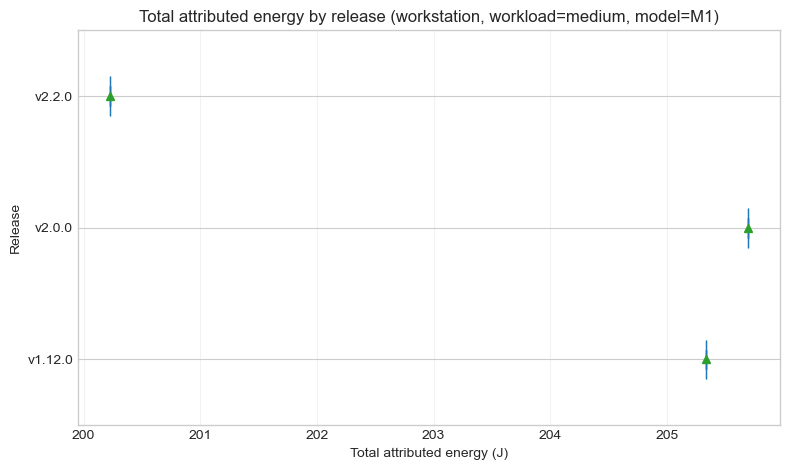

In [33]:
attr_wl = attr_df[
    (attr_df['workload_level'] == ATTRIBUTION_WORKLOAD)
    & (attr_df['model'] == ATTRIBUTION_MODEL)
]

if attr_wl.empty:
    raise RuntimeError(
        f'No attribution rows for workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL}'
    )

# Sum services per experiment to get total attributed energy
attr_total_per_experiment = (
    attr_wl.groupby(['environment', 'release', 'experiment_folder'], observed=True)['mean_attributed_energy_j']
    .sum()
    .reset_index(name='total_attributed_energy_j')
)

attr_total_summary = (
    attr_total_per_experiment.groupby(['environment', 'release'], observed=True)['total_attributed_energy_j']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values(['environment', 'release'])
    .reset_index(drop=True)
)

print('Output 3 summary:')
display(attr_total_summary.round(6))

style_map = {
    'workstation': {'color': '#1f77b4'},
    'ec2': {'color': '#d62728'},
}
swap_axes = bool(globals().get('SWAP_SIMPLE_RELEASE_AXES', False))

for env in ENV_ORDER:
    env_rows = attr_total_per_experiment[attr_total_per_experiment['environment'] == env].copy()
    if env_rows.empty:
        continue

    data = []
    labels = []
    for rel in RELEASE_ORDER:
        vals = pd.to_numeric(
            env_rows.loc[env_rows['release'] == rel, 'total_attributed_energy_j'],
            errors='coerce',
        ).dropna()
        if vals.empty:
            continue
        data.append(vals.to_numpy())
        labels.append(str(rel))

    if not data:
        continue

    color = style_map[env]['color']
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    bp = ax.boxplot(
        data,
        tick_labels=labels,
        vert=not swap_axes,
        patch_artist=True,
        showmeans=True,
    )
    for box in bp['boxes']:
        box.set(facecolor=color, alpha=0.25, edgecolor=color)
    for key in ['whiskers', 'caps', 'medians', 'means']:
        for artist in bp[key]:
            artist.set(color=color)

    ax.set_title(
        f'Total attributed energy by release ({env}, workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL})'
    )
    if swap_axes:
        ax.set_ylabel('Release')
        ax.set_xlabel('Total attributed energy (J)')
        ax.grid(True, axis='x', alpha=0.25)
    else:
        ax.set_xlabel('Release')
        ax.set_ylabel('Total attributed energy (J)')
        ax.grid(True, axis='y', alpha=0.25)

    fig.tight_layout()
    save_figure(fig, f'output3_{env}_{ATTRIBUTION_WORKLOAD}_{ATTRIBUTION_MODEL}')
    plt.show()

Output 3b excluded services=['load-generator']; unique services 22 -> 21
Output 3b (workstation) services shown: ['frontend', 'product-catalog', 'frontend-proxy', 'kafka', 'checkout', 'cart', 'product-reviews', 'llm', 'fraud-detection', 'recommendation']


release,v1.12.0,v2.0.0,v2.2.0
service,,,
frontend,51.849060,51.550041,51.520490
product-catalog,50.114084,49.955801,45.082233
frontend-proxy,8.488984,8.440611,8.436724
kafka,4.597783,4.528114,4.571570
checkout,3.478524,3.617504,3.138577
cart,2.910118,3.013746,2.962680
product-reviews,2.352117,2.316447,2.260764
llm,2.277219,2.290134,2.288061
fraud-detection,1.899381,1.921609,1.973632


Saved figure: figures/output3b_workstation_medium_m1.png and figures/output3b_workstation_medium_m1.pdf


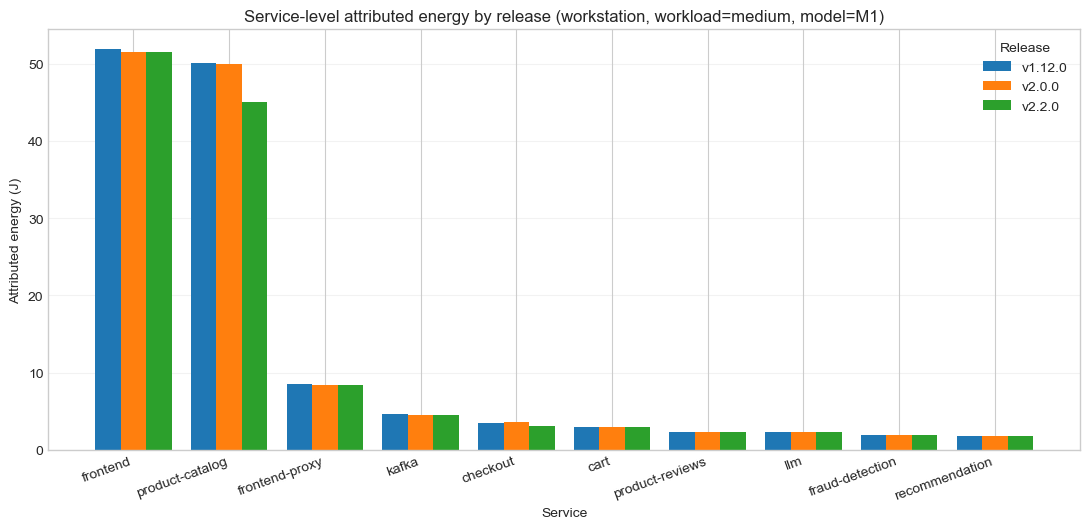

In [34]:
service_attr = attr_df[
    (attr_df['workload_level'] == ATTRIBUTION_WORKLOAD)
    & (attr_df['model'] == ATTRIBUTION_MODEL)
] .copy()

if service_attr.empty:
    raise RuntimeError(
        f'No service attribution rows for workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL}'
    )

top_n = int(globals().get('SERVICE_BREAKDOWN_TOP_N', 6))
excluded_services = {
    str(s).strip().lower() for s in globals().get('EXCLUDED_SERVICES', []) if str(s).strip()
}

if excluded_services:
    before_n = service_attr['service'].nunique()
    service_attr = service_attr[
        ~service_attr['service'].astype(str).str.lower().isin(excluded_services)
    ].copy()
    after_n = service_attr['service'].nunique()
    print(
        f'Output 3b excluded services={sorted(excluded_services)}; '
        f'unique services {before_n} -> {after_n}'
    )

if service_attr.empty:
    raise RuntimeError('No service rows left after applying EXCLUDED_SERVICES filter.')

service_summary_long = (
    service_attr.groupby(['environment', 'release', 'service'], observed=True)['mean_attributed_energy_j']
    .mean()
    .reset_index()
)

for env in ENV_ORDER:
    env_df = service_summary_long[service_summary_long['environment'] == env].copy()
    if env_df.empty:
        continue

    pivot = env_df.pivot(index='service', columns='release', values='mean_attributed_energy_j').fillna(0.0)
    pivot = pivot.reindex(columns=RELEASE_ORDER).fillna(0.0)

    ranked_services = pivot.mean(axis=1).sort_values(ascending=False).index.tolist()
    top_services = ranked_services[:top_n]
    plot_df = pivot.loc[top_services].copy()

    print(f'Output 3b ({env}) services shown:', list(plot_df.index))
    display(plot_df.round(6))

    x = np.arange(len(plot_df.index))
    n_releases = len(RELEASE_ORDER)
    width = 0.8 / max(n_releases, 1)

    fig, ax = plt.subplots(figsize=(11.0, 5.4))
    for idx, rel in enumerate(RELEASE_ORDER):
        offset = (idx - (n_releases - 1) / 2) * width
        ax.bar(
            x + offset,
            plot_df[rel].to_numpy(),
            width=width,
            label=rel,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index.tolist(), rotation=20, ha='right')
    ax.set_title(
        f'Service-level attributed energy by release ({env}, workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL})'
    )
    ax.set_xlabel('Service')
    ax.set_ylabel('Attributed energy (J)')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(title='Release')
    fig.tight_layout()
    save_figure(fig, f'output3b_{env}_{ATTRIBUTION_WORKLOAD}_{ATTRIBUTION_MODEL}')
    plt.show()

Output 3c summary:


,environment,group,release,mean,std,count
0,workstation,Application total,v1.12.0,205.334463,NaN,1
1,workstation,Application total,v2.0.0,205.696695,NaN,1
2,workstation,Application total,v2.2.0,200.227086,NaN,1
3,workstation,Service: cart,v1.12.0,2.910118,NaN,1
4,workstation,Service: cart,v2.0.0,3.013746,NaN,1
5,workstation,Service: cart,v2.2.0,2.962680,NaN,1


Saved figure: figures/output3c_workstation_medium_m1_cart.png and figures/output3c_workstation_medium_m1_cart.pdf


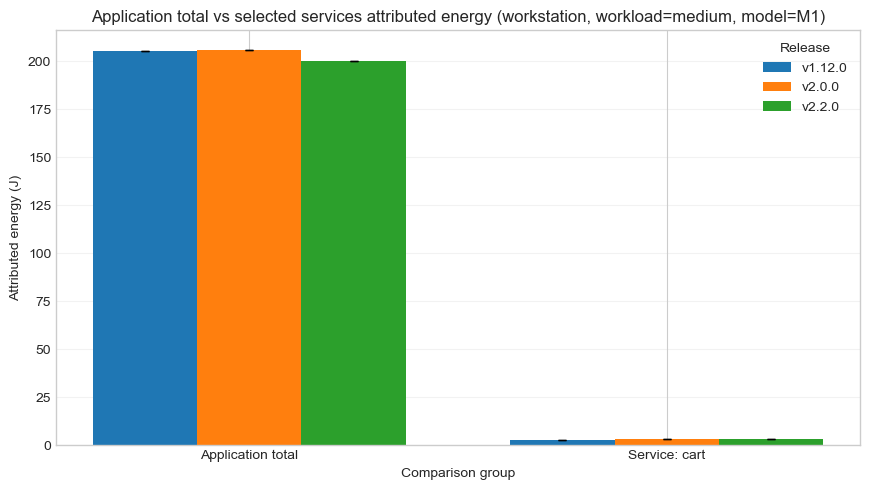

In [35]:
comparison_attr = attr_df[
    (attr_df['workload_level'] == ATTRIBUTION_WORKLOAD)
    & (attr_df['model'] == ATTRIBUTION_MODEL)
]

if comparison_attr.empty:
    raise RuntimeError(
        f'No attribution rows for workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL}'
    )

target_services = [
    str(s).strip()
    for s in globals().get('TARGET_SERVICES', [globals().get('TARGET_SERVICE', '')])
    if str(s).strip()
]
if not target_services:
    raise RuntimeError('No services configured. Set TARGET_SERVICES in the input cell.')

# Group A: total attributed application energy (sum across services, then mean across experiments).
application_total = (
    comparison_attr.groupby(['environment', 'release', 'experiment_folder'], observed=True)['mean_attributed_energy_j']
    .sum()
    .reset_index(name='value_j')
)
application_total['group'] = 'Application total'

# Group B+: selected service attributed energy (mean across experiments) for each configured service.
service_frames = []
found_services = []
for service_name in target_services:
    svc_df = (
        comparison_attr[comparison_attr['service'].astype(str) == service_name]
        .groupby(['environment', 'release', 'experiment_folder'], observed=True)['mean_attributed_energy_j']
        .mean()
        .reset_index(name='value_j')
    )
    if svc_df.empty:
        print(
            f'WARNING: no attribution rows found for service={service_name} under '
            f'workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL}'
        )
        continue
    svc_df['group'] = f'Service: {service_name}'
    service_frames.append(svc_df)
    found_services.append(service_name)

if not service_frames:
    raise RuntimeError(
        'No attribution rows found for any configured TARGET_SERVICES under current workload/model filters.'
    )

combo = pd.concat([application_total] + service_frames, ignore_index=True)

combo_summary = (
    combo.groupby(['environment', 'group', 'release'], observed=True)['value_j']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values(['environment', 'group', 'release'])
    .reset_index(drop=True)
)

print('Output 3c summary:')
display(combo_summary.round(6))

group_order = ['Application total'] + [f'Service: {s}' for s in found_services]
n_releases = len(RELEASE_ORDER)
width = 0.75 / max(n_releases, 1)

for env in ENV_ORDER:
    env_df = combo_summary[combo_summary['environment'] == env].copy()
    if env_df.empty:
        continue

    fig, ax = plt.subplots(figsize=(max(8.8, 2.2 * len(group_order)), 5.0))
    x = np.arange(len(group_order))

    for idx, rel in enumerate(RELEASE_ORDER):
        offset = (idx - (n_releases - 1) / 2) * width
        vals = []
        errs = []
        for grp in group_order:
            row = env_df[(env_df['group'] == grp) & (env_df['release'] == rel)]
            if row.empty:
                vals.append(0.0)
                errs.append(0.0)
            else:
                vals.append(float(row['mean'].iloc[0]))
                errs.append(float(row['std'].fillna(0.0).iloc[0]))

        ax.bar(
            x + offset,
            vals,
            width=width,
            yerr=errs,
            capsize=3,
            label=rel,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(group_order)
    ax.set_xlabel('Comparison group')
    ax.set_ylabel('Attributed energy (J)')
    ax.set_title(
        f'Application total vs selected services attributed energy ({env}, workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL})'
    )
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(title='Release')
    fig.tight_layout()
    save_figure(
        fig,
        f"output3c_{env}_{ATTRIBUTION_WORKLOAD}_{ATTRIBUTION_MODEL}_{'_'.join(found_services)}",
    )
    plt.show()

Output 3c iteration-level summary (selected service):


,environment,release,mean,std,count
0,workstation,v1.12.0,2.910118,0.607932,20
1,workstation,v2.0.0,3.013746,0.742795,20
2,workstation,v2.2.0,2.962680,0.613963,20


Saved figure: figures/output3c_boxplot_iter_rotated_workstation_cart_medium_m1.png and figures/output3c_boxplot_iter_rotated_workstation_cart_medium_m1.pdf


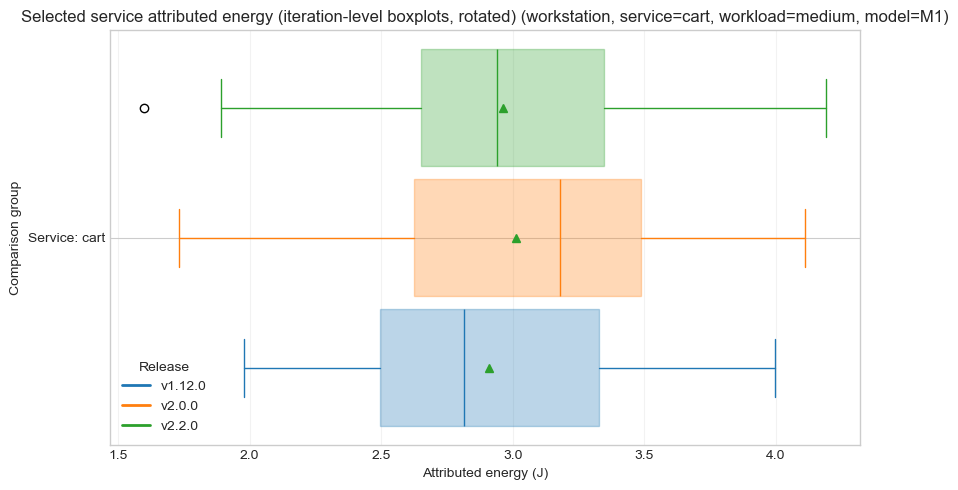

In [36]:
# Output 3c (boxplot redraw): selected service only, rotated, using iteration-level attribution
# This version reads per-iteration service attribution CSVs so boxplots can show true spread.

service_label = f"Service: {TARGET_SERVICE}"

iter_rows = []
for release, release_dir in RELEASE_PATHS.items():
    experiments = iter_experiment_dirs(release_dir)
    if not experiments:
        continue

    for experiment_dir, env in experiments:
        wl_dir = experiment_dir / str(ATTRIBUTION_WORKLOAD)
        if not wl_dir.exists() or not wl_dir.is_dir():
            continue

        for iteration_dir in sorted(wl_dir.glob('iteration_*')):
            csv_path = iteration_dir / 'attribution' / 'service_attribution.csv'
            if not csv_path.exists():
                continue

            try:
                sdf = pd.read_csv(csv_path)
            except Exception:
                continue

            required_cols = {'model_variant', 'service_name', 'allocated_energy_joules'}
            if not required_cols.issubset(set(sdf.columns)):
                continue

            row = sdf[
                (sdf['model_variant'].astype(str) == str(ATTRIBUTION_MODEL))
                & (sdf['service_name'].astype(str) == str(TARGET_SERVICE))
            ]
            if row.empty:
                continue

            val = pd.to_numeric(row['allocated_energy_joules'], errors='coerce').dropna()
            if val.empty:
                continue

            iter_rows.append(
                {
                    'release': release,
                    'environment': env,
                    'group': service_label,
                    'iteration_name': iteration_dir.name,
                    'value_j': float(val.iloc[0]),
                }
            )

iter_df = pd.DataFrame(iter_rows)
if iter_df.empty:
    raise RuntimeError(
        'No iteration-level attribution samples found for current settings. '
        'Check TARGET_SERVICE / ATTRIBUTION_MODEL / ATTRIBUTION_WORKLOAD.'
    )

iter_df['release'] = pd.Categorical(iter_df['release'], categories=RELEASE_ORDER, ordered=True)
iter_df['environment'] = pd.Categorical(iter_df['environment'], categories=ENV_ORDER, ordered=True)

iter_summary = (
    iter_df.groupby(['environment', 'release'], observed=True)['value_j']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values(['environment', 'release'])
    .reset_index(drop=True)
)
print('Output 3c iteration-level summary (selected service):')
display(iter_summary.round(6))

group_order = [service_label]
n_releases = len(RELEASE_ORDER)
box_width = 0.75 / max(n_releases, 1)

for env in ENV_ORDER:
    env_df = iter_df[iter_df['environment'] == env].copy()
    if env_df.empty:
        continue

    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    y_base = np.arange(len(group_order), dtype=float)

    for idx, rel in enumerate(RELEASE_ORDER):
        offset = (idx - (n_releases - 1) / 2) * box_width
        data = []
        pos = []

        vals = pd.to_numeric(
            env_df[(env_df['group'] == service_label) & (env_df['release'] == rel)]['value_j'],
            errors='coerce',
        ).dropna()
        if not vals.empty:
            data.append(vals.to_numpy())
            pos.append(y_base[0] + offset)

        if not data:
            continue

        bp = ax.boxplot(
            data,
            positions=pos,
            widths=box_width * 0.9,
            patch_artist=True,
            showmeans=True,
            manage_ticks=False,
            vert=False,
        )

        color = plt.cm.tab10(idx % 10)
        for box in bp['boxes']:
            box.set(facecolor=color, alpha=0.3, edgecolor=color)
        for key in ['whiskers', 'caps', 'medians', 'means']:
            for artist in bp[key]:
                artist.set(color=color)

    ax.set_yticks(y_base)
    ax.set_yticklabels(group_order)
    ax.set_ylabel('Comparison group')
    ax.set_xlabel('Attributed energy (J)')
    ax.set_title(
        f'Selected service attributed energy (iteration-level boxplots, rotated) ({env}, service={TARGET_SERVICE}, workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL})'
    )
    ax.grid(True, axis='x', alpha=0.25)

    handles = [
        plt.Line2D([0], [0], color=plt.cm.tab10(i % 10), lw=2, label=rel)
        for i, rel in enumerate(RELEASE_ORDER)
    ]
    ax.legend(handles=handles, title='Release')

    fig.tight_layout()
    save_figure(
        fig,
        f"output3c_boxplot_iter_rotated_{env}_{TARGET_SERVICE}_{ATTRIBUTION_WORKLOAD}_{ATTRIBUTION_MODEL}",
    )
    plt.show()

### Output 3c: Application Total vs Selected Service (Absolute Attributed Energy)

This chart compares two groups per environment:
1. Total application attributed energy over releases.
2. Selected service attributed energy over releases (configured by TARGET_SERVICE).

### Output 3b: Service-level attribution breakdown over releases

This restores the multi-service view as stacked bars per release, with one chart per environment.

## Output 4: Fixed-utilisation energy/request for selected service over releases

This output mirrors the fixed-util system EPR logic and estimates selected-service EPR as:
selected service share of attributed energy * fixed-util system EPR.

Use TARGET_SERVICE, ATTRIBUTION_WORKLOAD, and ATTRIBUTION_MODEL to configure it.

Output 4 summary (fixed-util selected service EPR):


,environment,release,system_epr_mean,system_epr_std,share_mean,share_std,service_epr_mean,service_epr_std
0,workstation,v1.12.0,0.001208,0.000047,0.014173,0.0,0.000017,6.600000e-07
1,workstation,v2.0.0,0.001206,0.000041,0.014651,0.0,0.000018,6.100000e-07
2,workstation,v2.2.0,0.001177,0.000098,0.014797,0.0,0.000017,1.440000e-06


Saved figure: figures/output4_workstation_cart_medium_m1.png and figures/output4_workstation_cart_medium_m1.pdf


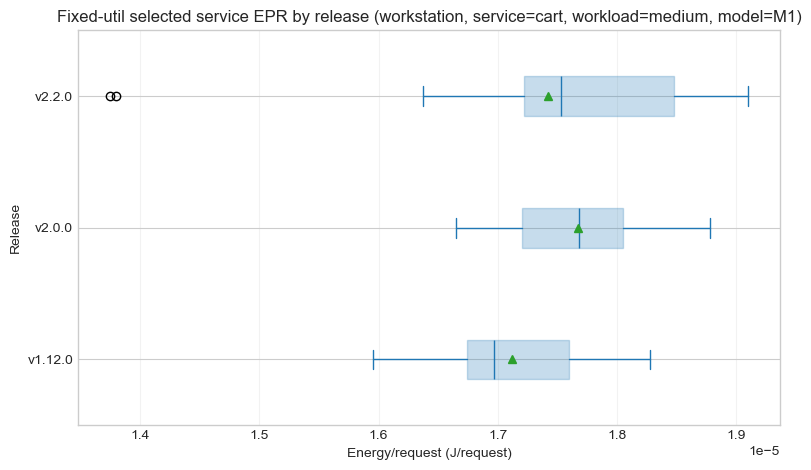

In [37]:
# Output 4: fixed-util service energy/request (similar basis to Output 2).
if 'fixed_util_selected' not in globals() or fixed_util_selected.empty:
    raise RuntimeError(
        'fixed_util_selected is missing. Run Output 2 first so fixed-util filtering is available.'
    )

# Fixed-util system EPR restricted to the workload used for service attribution.
fixed_util_base = fixed_util_selected[
    fixed_util_selected['workload_level'].astype(str) == str(ATTRIBUTION_WORKLOAD)
] .copy()

if fixed_util_base.empty:
    raise RuntimeError(
        f'No fixed-util rows for ATTRIBUTION_WORKLOAD={ATTRIBUTION_WORKLOAD}. '
        'Adjust workload settings or rerun Output 2.'
    )

overall_fixed = (
    fixed_util_base.groupby(['environment', 'release'], observed=True)['energy_per_request_j']
    .agg(system_epr_mean=('mean'), system_epr_std=('std'), n_system=('count'))
    .reset_index()
)
overall_fixed['system_epr_std'] = overall_fixed['system_epr_std'].fillna(0.0)

# Attribution share for selected service at experiment level.
attr_subset = attr_df[
    (attr_df['workload_level'].astype(str) == str(ATTRIBUTION_WORKLOAD))
    & (attr_df['model'].astype(str) == str(ATTRIBUTION_MODEL))
] .copy()

if attr_subset.empty:
    raise RuntimeError(
        f'No attribution rows for workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL}'
    )

total_attr_exp = (
    attr_subset.groupby(['environment', 'release', 'experiment_folder'], observed=True)['mean_attributed_energy_j']
    .sum()
    .reset_index(name='total_attr_j')
)

service_attr_exp = (
    attr_subset[attr_subset['service'].astype(str) == str(TARGET_SERVICE)]
    .groupby(['environment', 'release', 'experiment_folder'], observed=True)['mean_attributed_energy_j']
    .mean()
    .reset_index(name='service_attr_j')
)

if service_attr_exp.empty:
    raise RuntimeError(
        f'No attribution rows found for service={TARGET_SERVICE} under workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL}'
    )

share_exp = total_attr_exp.merge(
    service_attr_exp,
    on=['environment', 'release', 'experiment_folder'],
    how='inner',
)
share_exp = share_exp[share_exp['total_attr_j'] > 0].copy()
share_exp['service_share'] = share_exp['service_attr_j'] / share_exp['total_attr_j']

share_summary = (
    share_exp.groupby(['environment', 'release'], observed=True)['service_share']
    .agg(share_mean=('mean'), share_std=('std'), n_share=('count'))
    .reset_index()
)
share_summary['share_std'] = share_summary['share_std'].fillna(0.0)

service_fixed = overall_fixed.merge(
    share_summary,
    on=['environment', 'release'],
    how='inner',
)

if service_fixed.empty:
    raise RuntimeError(
        'No overlap between fixed-util EPR rows and selected service attribution share rows.'
    )

service_fixed['service_epr_mean'] = service_fixed['system_epr_mean'] * service_fixed['share_mean']
service_fixed['service_epr_std'] = np.sqrt(
    (service_fixed['share_mean'] * service_fixed['system_epr_std']) ** 2
    + (service_fixed['system_epr_mean'] * service_fixed['share_std']) ** 2
)

# Build iteration-level service EPR samples for boxplots.
service_fixed_exp = fixed_util_base.merge(
    share_exp[['environment', 'release', 'experiment_folder', 'service_share']],
    on=['environment', 'release', 'experiment_folder'],
    how='inner',
)
service_fixed_exp['service_epr_j'] = (
    service_fixed_exp['energy_per_request_j'] * service_fixed_exp['service_share']
)

if service_fixed_exp.empty:
    raise RuntimeError('No iteration-level rows available for Output 4 boxplots.')

print('Output 4 summary (fixed-util selected service EPR):')
display(
    service_fixed[
        [
            'environment', 'release',
            'system_epr_mean', 'system_epr_std',
            'share_mean', 'share_std',
            'service_epr_mean', 'service_epr_std',
        ]
    ].round(8)
)

style_map = {
    'workstation': {'color': '#1f77b4'},
    'ec2': {'color': '#d62728'},
}
swap_axes = bool(globals().get('SWAP_SIMPLE_RELEASE_AXES', False))

for env in ENV_ORDER:
    env_rows = service_fixed_exp[service_fixed_exp['environment'] == env].copy()
    if env_rows.empty:
        continue

    data = []
    labels = []
    for rel in RELEASE_ORDER:
        vals = pd.to_numeric(
            env_rows.loc[env_rows['release'] == rel, 'service_epr_j'],
            errors='coerce',
        ).dropna()
        if vals.empty:
            continue
        data.append(vals.to_numpy())
        labels.append(str(rel))

    if not data:
        continue

    color = style_map[env]['color']
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    bp = ax.boxplot(
        data,
        tick_labels=labels,
        vert=not swap_axes,
        patch_artist=True,
        showmeans=True,
    )
    for box in bp['boxes']:
        box.set(facecolor=color, alpha=0.25, edgecolor=color)
    for key in ['whiskers', 'caps', 'medians', 'means']:
        for artist in bp[key]:
            artist.set(color=color)

    ax.set_title(
        f'Fixed-util selected service EPR by release ({env}, service={TARGET_SERVICE}, workload={ATTRIBUTION_WORKLOAD}, model={ATTRIBUTION_MODEL})'
    )
    if swap_axes:
        ax.set_ylabel('Release')
        ax.set_xlabel('Energy/request (J/request)')
        ax.grid(True, axis='x', alpha=0.25)
    else:
        ax.set_xlabel('Release')
        ax.set_ylabel('Energy/request (J/request)')
        ax.grid(True, axis='y', alpha=0.25)

    fig.tight_layout()
    save_figure(fig, f'output4_{env}_{TARGET_SERVICE}_{ATTRIBUTION_WORKLOAD}_{ATTRIBUTION_MODEL}')
    plt.show()